# ASSIGNMENT 5

This report presents a brief exploratory data analysis (EDA) of the cardiotocographic dataset, which contains fetal heart rate (FHR) measurements and related clinical indicators. The objective of this analysis is to understand the structure of the dataset, identify patterns, detect anomalies, and extract meaningful insights that can support further analysis or predictive modeling.

In [2]:
# Import required libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Apply a nice visual style for plots
sns.set(style="whitegrid")


In [3]:
# Load the cardiotocographic dataset
df = pd.read_csv("cardiotocographic.csv")

# Display the first five rows to understand the data structure
df.head()


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [4]:
# Display dataset information such as column names, data types, and null values
df.info()

# Display the number of rows and columns
df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


(2126, 14)

In [5]:
# Check for missing values in each column
df.isnull().sum()


LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

In [6]:
# Convert all columns to numeric values
# Any non-numeric values will be converted to NaN
df = df.apply(pd.to_numeric, errors='coerce')

# Check missing values again after conversion
df.isnull().sum()
    

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

In [7]:
# Fill missing values using median to avoid the influence of outliers
df.fillna(df.median(), inplace=True)


# Statistical summary

In [8]:
# Generate statistical summary of the dataset
# Includes mean, median, standard deviation, and quartiles
df.describe()


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.340204,0.003204,0.009894,0.004391,0.001895,0.000002,0.000173,46.995984,1.364378,10.285964,8.276147,70.395387,0.313246,1.301499
std,11.214379,0.004373,0.067540,0.003340,0.003343,0.000141,0.000836,18.813973,1.173632,21.205041,7.734851,42.720508,0.643186,0.642133
min,51.842487,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,-63.000000,-6.600000,-91.000000,-50.700000,-174.000000,-3.000000,-1.025988
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
50%,133.000000,0.001634,0.000000,0.004484,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.000000
75%,140.000000,0.005606,0.002567,0.006536,0.003289,0.000000,0.000000,61.000000,1.700000,11.000000,10.800000,100.000000,1.000000,1.000000
max,214.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,162.000000,13.800000,182.000000,101.400000,357.000000,3.000000,5.000000


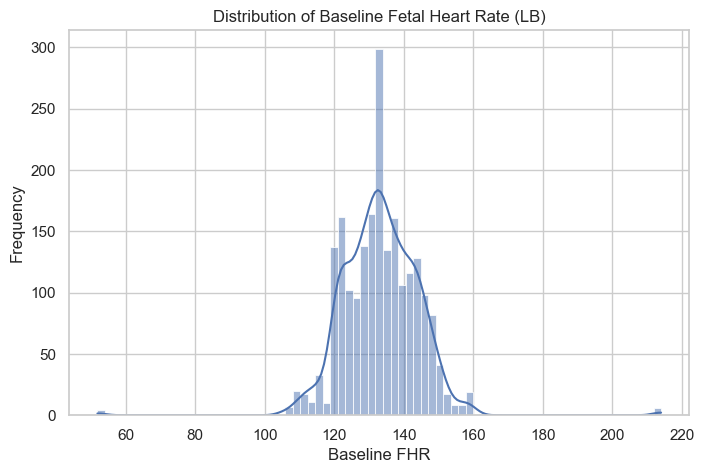

In [9]:
# Plot histogram to visualize the distribution of Baseline Fetal Heart Rate (LB)
plt.figure(figsize=(8,5))
sns.histplot(df['LB'], kde=True)
plt.title("Distribution of Baseline Fetal Heart Rate (LB)")
plt.xlabel("Baseline FHR")
plt.ylabel("Frequency")
plt.show()


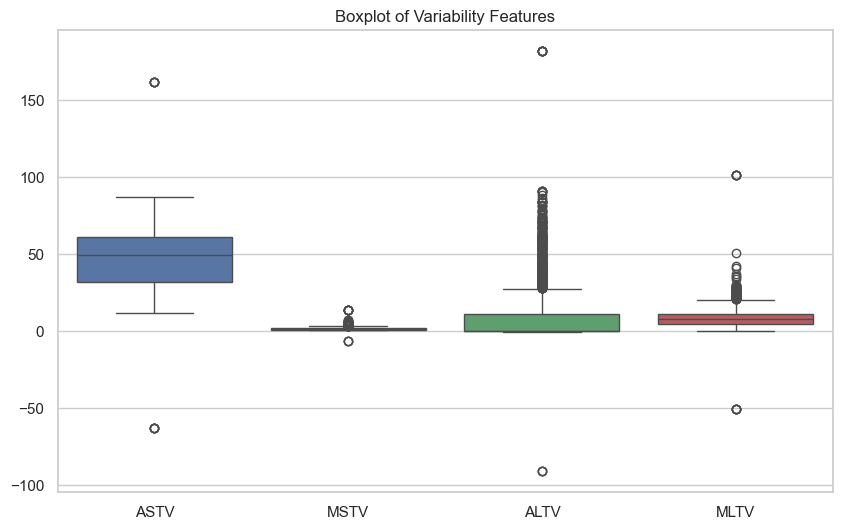

In [10]:
# Plot boxplots for important variability features to identify outliers
features = ['ASTV', 'MSTV', 'ALTV', 'MLTV']
plt.figure(figsize=(10,6))
sns.boxplot(data=df[features])
plt.title("Boxplot of Variability Features")
plt.show()


In [11]:
# Display count of each fetal health class (NSP)
df['NSP'].value_counts()


NSP
 1.000000    1567
 2.000000     280
 3.000000     164
-1.000000       5
 5.000000       4
             ... 
 0.993695       1
 1.013864       1
 0.989862       1
 1.004234       1
 1.990464       1
Name: count, Length: 111, dtype: int64

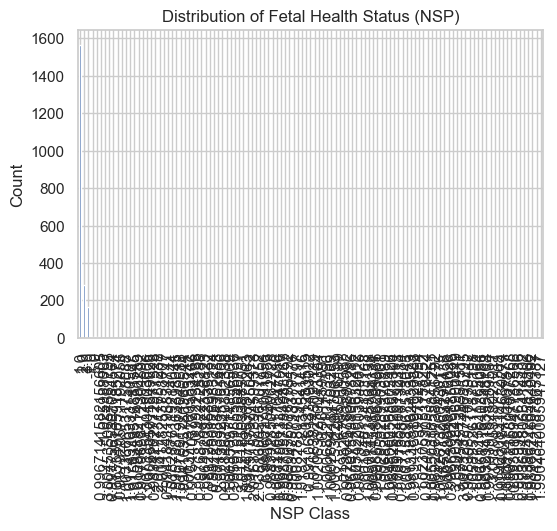

In [12]:
# Visualize the distribution of fetal health states using bar chart
plt.figure(figsize=(6,4))
df['NSP'].value_counts().plot(kind='bar')
plt.title("Distribution of Fetal Health Status (NSP)")
plt.xlabel("NSP Class")
plt.ylabel("Count")
plt.show()


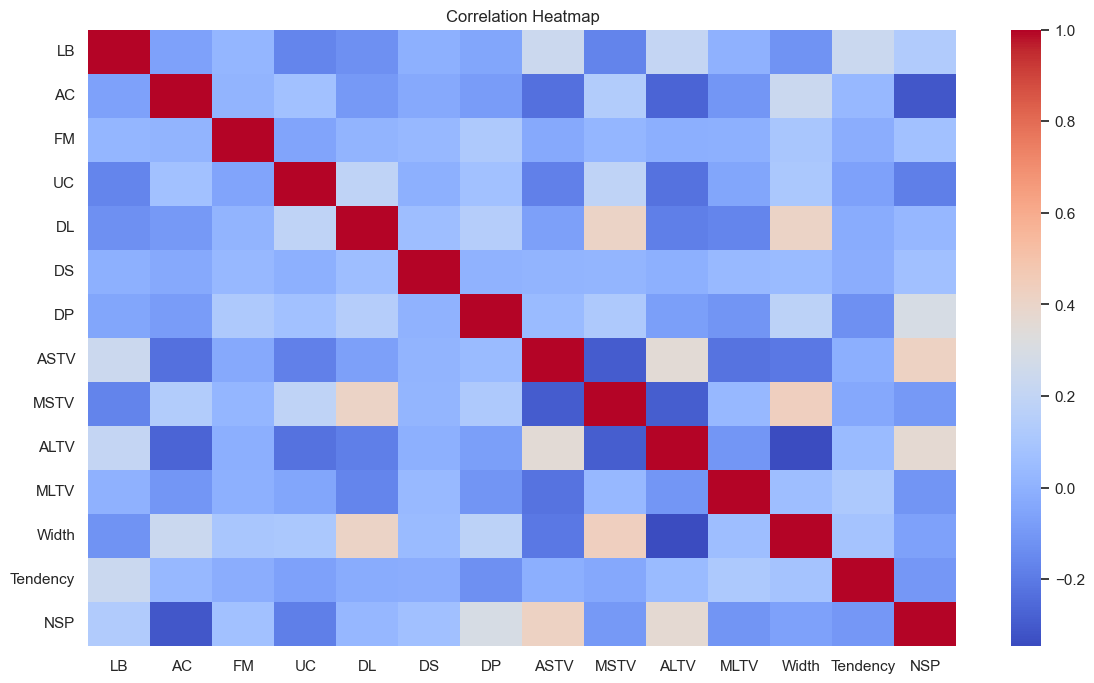

In [13]:
# Calculate correlation matrix to understand relationships between variables
correlation_matrix = df.corr()

# Plot correlation heatmap
plt.figure(figsize=(14,8))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()


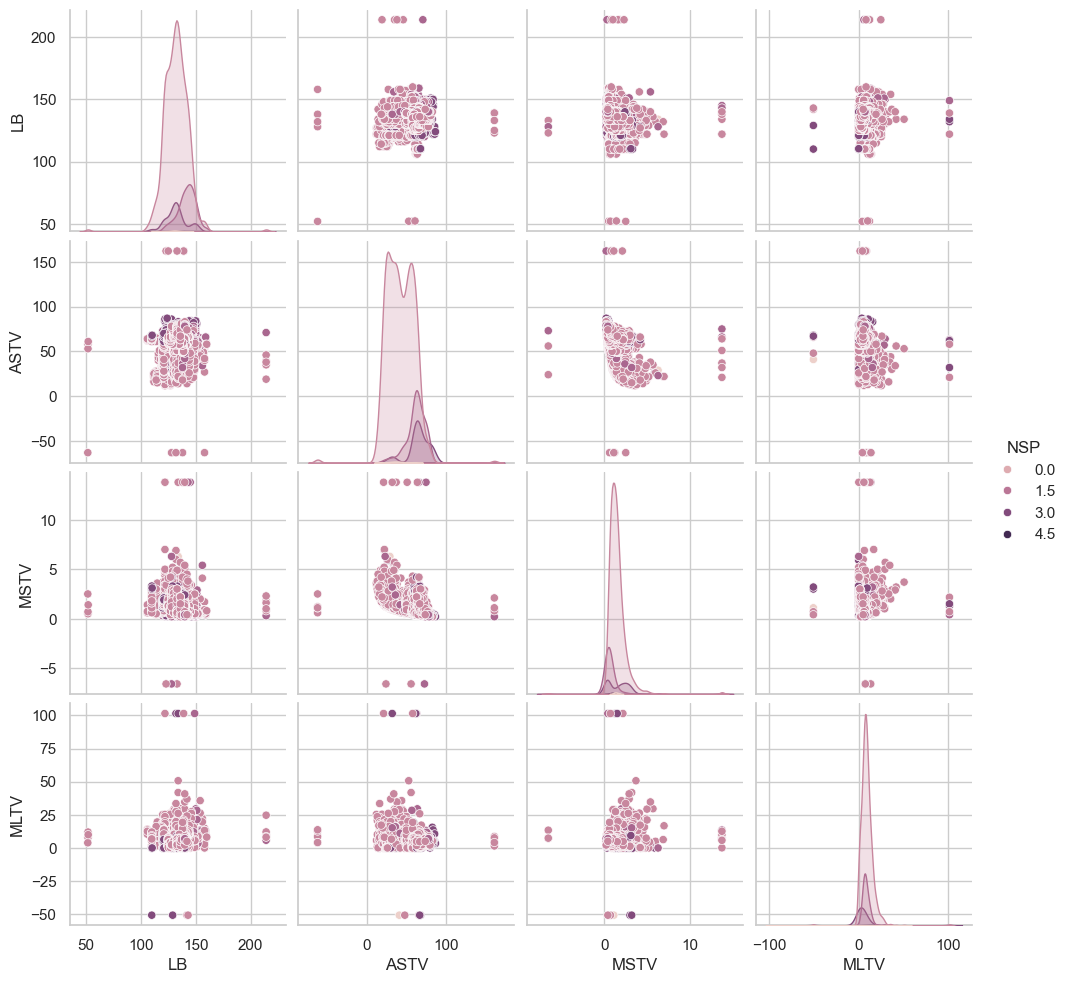

In [14]:
# Create pair plot to analyze relationships among selected features and target variable
sns.pairplot(df[['LB', 'ASTV', 'MSTV', 'MLTV', 'NSP']], hue='NSP')
plt.show()


In [15]:
# Calculate Interquartile Range (IQR) to identify extreme outliers
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

# Remove records containing extreme outliers (optional step)
df_cleaned = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

# Compare dataset size before and after outlier removal
print("Original dataset size:", df.shape)
print("After outlier removal:", df_cleaned.shape)


Original dataset size: (2126, 14)
After outlier removal: (896, 14)


In [16]:
# Identify features most correlated with fetal health status (NSP)
df.corr()['NSP'].sort_values(ascending=False)


NSP         1.000000
ASTV        0.420873
ALTV        0.366454
DP          0.295057
LB          0.131839
FM          0.074446
DS          0.065411
DL          0.024879
Width      -0.066974
MSTV       -0.095876
Tendency   -0.103713
MLTV       -0.113011
UC         -0.185229
AC         -0.311689
Name: NSP, dtype: float64

In [17]:
# Save cleaned dataset for future analysis or modeling
df.to_csv("cardiotocographic_cleaned.csv", index=False)


# Conclusion

The exploratory data analysis provides valuable insights into the cardiotocographic dataset. It highlights the importance of heart rate variability in fetal health assessment and confirms the dataset’s suitability for further predictive and analytical studies.